# Boosting in Machine Learning - Assignment Answers
**Total Marks: 78 (6 marks each)**

---

## Question 1: What is Boosting in Machine Learning?

**Answer:**

Boosting is an ensemble learning technique where we combine multiple weak learners to create a strong learner. A weak learner is a simple model that performs only slightly better than random guessing, like a shallow decision tree.

The core idea is sequential learning - we train models one after another, where each new model focuses on correcting the mistakes made by previous models. The first model is trained on the original data, then we identify which examples it got wrong. The next model pays special attention to these misclassified examples by giving them higher weights. This process continues, with each model learning from the cumulative errors of all previous models.

Finally, all models are combined using weighted voting or averaging. Better-performing models get more weight in the final prediction. This sequential error-correction approach transforms weak learners into a powerful ensemble that achieves high accuracy on complex problems.

---

## Question 2: How does Boosting differ from Bagging?

**Answer:**

Boosting and Bagging differ in several fundamental ways:

**Training Process:** Bagging trains all models independently and simultaneously, while Boosting trains models sequentially where each model learns from previous mistakes.

**Data Handling:** Bagging creates multiple datasets through random sampling with replacement (bootstrap), giving each model a different data subset. Boosting uses the same dataset but adjusts example weights - misclassified examples get higher weights for subsequent models.

**Model Combination:** In Bagging, all models have equal voting power. In Boosting, models are weighted based on their accuracy, giving better models more influence.

**Primary Goal:** Bagging reduces variance and prevents overfitting, working well with high-variance models like deep trees. Boosting reduces bias and improves weak models by iteratively correcting errors.

**Overfitting Risk:** Bagging is less prone to overfitting due to independent models. Boosting can overfit if too many iterations are used or data is noisy, requiring careful tuning.

---

## Question 3: What is the key idea behind AdaBoost?

**Answer:**

AdaBoost (Adaptive Boosting) is based on the idea of adaptively adjusting to the errors of weak classifiers. The key concept is to give more importance to difficult examples that previous models got wrong.

The process starts by assigning equal weights to all training examples. A weak classifier (typically a decision stump - a tree with just one split) is trained on this weighted data. After training, we evaluate which examples were misclassified.

Here's the adaptive part: examples that were predicted incorrectly get their weights increased, while correctly classified examples get their weights decreased. This forces the next classifier to pay more attention to the difficult cases. Additionally, each classifier itself gets a weight based on its accuracy - more accurate classifiers have more influence on the final prediction.

This continues for a specified number of iterations or until a desired accuracy is reached. The final model is a weighted sum of all weak classifiers. The beauty of AdaBoost is that it's adaptive - it automatically adjusts to focus computational effort where it's most needed, on the hardest examples.

---

## Question 4: Explain the working of AdaBoost with an example.

**Answer:**

Let's understand AdaBoost with a simple example of classifying emails as spam or not spam.

**Initial Setup:** Suppose we have 10 emails. Initially, each email gets equal weight of 0.1 (weights sum to 1).

**Iteration 1:** Train a weak classifier (decision stump) that checks "Does email contain 'free'?" It correctly classifies 7 emails and misclassifies 3. We calculate the classifier's error rate: 3/10 = 0.3. Based on this error, we calculate the classifier weight (alpha) - lower error gives higher weight. The 3 misclassified emails get their weights increased (say from 0.1 to 0.15 each), while the 7 correct ones get weights decreased (to about 0.07 each).

**Iteration 2:** Train another decision stump with the new weights. This time it might check "Does email have sender from unknown domain?" Because the previously misclassified emails now have higher weights, this classifier focuses more on getting those right. It might correctly classify some of the previously difficult cases.

**Iteration 3:** Continue this process. Each new classifier focuses increasingly on the stubborn examples that multiple previous classifiers got wrong.

**Final Prediction:** To classify a new email, we run it through all classifiers. Each classifier votes (spam/not spam), weighted by its accuracy. Sum up the weighted votes and take the sign to get the final prediction. This combined model is much stronger than any individual weak classifier.

---

## Question 5: What is Gradient Boosting, and how is it different from AdaBoost?

**Answer:**

Gradient Boosting is a boosting technique that builds models sequentially by fitting each new model to the residual errors (the difference between actual and predicted values) of the previous models. It frames the boosting problem as an optimization task where we minimize a loss function using gradient descent.

**How it differs from AdaBoost:**

**Error Handling:** AdaBoost adjusts example weights based on misclassification, while Gradient Boosting directly fits new models to the residual errors (actual minus predicted values). It's more like fixing the leftover mistakes rather than reweighting examples.

**Loss Function:** AdaBoost uses an exponential loss function implicitly, while Gradient Boosting can work with any differentiable loss function (MSE for regression, log loss for classification, etc.), making it much more flexible.

**Problem Types:** AdaBoost was primarily designed for classification, while Gradient Boosting naturally handles both classification and regression problems equally well.

**Model Weighting:** AdaBoost calculates explicit weights for each classifier based on accuracy. Gradient Boosting uses a learning rate to scale each model's contribution, providing finer control over the learning process.

**Robustness:** Gradient Boosting is generally more robust to outliers and noisy data because it works with residuals and allows custom loss functions. AdaBoost can be sensitive to outliers since they get high weights.

---

## Question 6: What is the loss function in Gradient Boosting?

**Answer:**

The loss function in Gradient Boosting measures how far our predictions are from the actual values, and different loss functions are used depending on the problem type.

**For Regression Problems:**
- **Mean Squared Error (MSE):** The most common choice. It penalizes large errors heavily, calculated as the average of squared differences between predicted and actual values.
- **Mean Absolute Error (MAE):** More robust to outliers, calculates average of absolute differences.
- **Huber Loss:** A hybrid that behaves like MSE for small errors and MAE for large errors, offering a balance.

**For Classification Problems:**
- **Log Loss (Binary Cross-Entropy):** Standard for binary classification, measures the performance of a model whose output is a probability between 0 and 1.
- **Multinomial Deviance:** Extension of log loss for multi-class problems.

The key insight is that Gradient Boosting computes the gradient (derivative) of the loss function with respect to predictions. Each new model is trained to predict these negative gradients (residuals), effectively taking a step in the direction that reduces the loss. This is why it's called "gradient" boosting - we're following the gradient to minimize the loss function.

The learning rate controls how big each step is, preventing overfitting by making smaller, more careful updates to predictions.

---

## Question 7: How does XGBoost improve over traditional Gradient Boosting?

**Answer:**

XGBoost (Extreme Gradient Boosting) introduces several key improvements that make it faster and more accurate than traditional Gradient Boosting:

**Regularization:** XGBoost includes L1 (Lasso) and L2 (Ridge) regularization terms in its objective function. This prevents overfitting by penalizing complex trees, something traditional Gradient Boosting lacks. It adds penalties for the number of leaves and leaf weights.

**System Optimization:** XGBoost is engineered for speed through parallelization. While trees are built sequentially, XGBoost parallelizes the node-splitting process across CPU cores. It also uses cache-aware access patterns and efficient data structures for faster computation.

**Handling Missing Values:** XGBoost automatically learns the best direction to handle missing values during training. For each split, it tries both directions and chooses the one that improves the loss most.

**Tree Pruning:** Unlike traditional methods that grow trees depth-wise and stop based on criteria, XGBoost grows trees to maximum depth and then prunes backward. This "max_depth" approach can discover splits that look unpromising initially but lead to good splits later.

**Built-in Cross-Validation:** XGBoost includes built-in cross-validation at each iteration, making it easy to find the optimal number of boosting rounds without overfitting.

**Sparsity Awareness:** It efficiently handles sparse data by only visiting non-missing values, making it great for datasets with many zeros or missing values.

---

## Question 8: What is the difference between XGBoost and CatBoost?

**Answer:**

While both are advanced gradient boosting libraries, XGBoost and CatBoost have distinct characteristics:

**Categorical Feature Handling:** This is CatBoost's biggest advantage. CatBoost has built-in intelligent handling of categorical variables using ordered target statistics, eliminating the need for manual encoding. XGBoost requires preprocessing categorical features through one-hot or label encoding before training.

**Ordered Boosting:** CatBoost uses ordered boosting, a technique that reduces overfitting by using different random permutations of data to calculate residuals. XGBoost uses standard gradient boosting.

**Default Parameters:** CatBoost often works well with default parameters and requires less tuning, making it more user-friendly for beginners. XGBoost typically needs careful hyperparameter tuning for optimal performance.

**Training Speed:** XGBoost is generally faster on datasets without many categorical features, especially with GPU acceleration. CatBoost can be slower but handles categorical data more efficiently without preprocessing overhead.

**Prediction Speed:** CatBoost produces symmetric trees, which are faster for making predictions. XGBoost creates asymmetric trees that are more accurate but slightly slower at inference.

**Overfitting:** CatBoost is more resistant to overfitting due to ordered boosting and has more conservative default parameters. XGBoost requires careful monitoring to prevent overfitting.

Both are excellent choices, with CatBoost being preferable when dealing with many categorical features, and XGBoost when working with numerical data and requiring maximum customization.

---

## Question 9: What are some real-world applications of Boosting techniques?

**Answer:**

Boosting techniques are widely used across industries due to their high accuracy and versatility:

**Finance:** Credit scoring and loan default prediction are classic applications. Banks use XGBoost to predict whether a borrower will default on a loan based on credit history, income, and other factors. Fraud detection systems use boosting to identify suspicious transactions in real-time by learning complex patterns that distinguish fraudulent from legitimate activity.

**E-commerce:** Recommendation systems use boosting to predict which products users will like. Search ranking algorithms employ boosting to order search results by relevance. Customer churn prediction helps businesses identify customers likely to leave and take preventive action.

**Healthcare:** Disease diagnosis models use boosting to predict diseases from symptoms and test results. Risk stratification systems identify high-risk patients who need immediate attention. Drug discovery research uses boosting to predict molecular properties and drug effectiveness.

**Technology:** Click-through rate (CTR) prediction for online advertising uses boosting extensively - companies like Google and Facebook use it to predict which ads users will click. Spam detection filters in email systems rely on boosting to separate spam from legitimate emails.

**Other Applications:** Insurance companies use it for risk assessment and premium calculation. Energy companies predict electricity load and consumption patterns. Transportation companies forecast demand and optimize routes. Weather forecasting services use it to improve prediction accuracy.

The common thread is that boosting excels when you need high accuracy on structured/tabular data with complex relationships.

---

## Question 10: How does regularization help in XGBoost?

**Answer:**

Regularization in XGBoost is crucial for preventing overfitting and creating models that generalize well to unseen data. It works through several mechanisms:

**L1 Regularization (Lasso):** Controlled by the `alpha` parameter, it adds a penalty proportional to the absolute value of leaf weights. This encourages sparsity, meaning it can push some leaf weights to exactly zero, effectively performing feature selection. This makes the model simpler and more interpretable.

**L2 Regularization (Ridge):** Controlled by the `lambda` parameter, it adds a penalty proportional to the square of leaf weights. This smooths the leaf weights, preventing any single feature from dominating the model. It creates more stable models that are less sensitive to individual data points.

**Tree Complexity Penalty:** The `gamma` parameter adds a penalty for each additional leaf in the tree. A higher gamma makes the algorithm more conservative about adding new splits. This prevents the creation of overly complex trees with too many leaves that memorize training data.

**Practical Benefits:** Regularization reduces variance in predictions, making the model more robust to noise in training data. It helps find the right balance between fitting the training data and maintaining simplicity. Models with appropriate regularization perform better on test data even if training accuracy is slightly lower.

**Tuning Strategy:** Start with default values and increase regularization parameters if you observe overfitting (large gap between training and validation accuracy). The combination of these regularization techniques gives XGBoost fine-grained control over model complexity.

---

## Question 11: What are some hyperparameters to tune in Gradient Boosting models?

**Answer:**

Tuning hyperparameters is essential for getting optimal performance from Gradient Boosting models. Here are the key parameters:

**Tree-Specific Parameters:**
- **max_depth:** Controls tree depth. Deeper trees capture more complex patterns but risk overfitting. Typical range: 3-10.
- **min_child_weight:** Minimum sum of weights needed in a leaf. Higher values prevent overfitting. Range: 1-10.
- **subsample:** Fraction of samples used for each tree. Values like 0.8 add randomness and prevent overfitting.
- **colsample_bytree:** Fraction of features used per tree. Typical values: 0.5-1.0. Adds diversity to trees.

**Boosting Parameters:**
- **n_estimators:** Number of trees to build. More trees increase accuracy but also training time and overfitting risk. Start with 100-500.
- **learning_rate (eta):** How much each tree contributes. Lower values (0.01-0.1) need more trees but generalize better. It's a crucial parameter - smaller is usually better with more trees.

**Regularization Parameters:**
- **reg_alpha (L1):** L1 regularization term. Start with 0, increase if overfitting occurs.
- **reg_lambda (L2):** L2 regularization term. Default is usually good, but try 1-10 if needed.
- **gamma:** Minimum loss reduction for splitting. Higher values make the model conservative.

**Tuning Strategy:** Start by tuning learning_rate and n_estimators together - lower learning rate requires more estimators. Then tune tree structure (max_depth, min_child_weight). Finally, add regularization if still overfitting. Use cross-validation to evaluate each configuration.

---

## Question 12: What is the concept of Feature Importance in Boosting?

**Answer:**

Feature Importance in Boosting measures how valuable each feature is for making predictions. It helps us understand which variables the model relies on most heavily.

**How It's Calculated:**
The most common method is based on split frequency and gain. When a feature is used to split data in a tree, it receives an importance score based on how much that split improved the model (reduced loss). Features used in more splits, especially near the root of trees where they affect more data, get higher importance scores. The scores are summed across all trees and normalized to a 0-1 scale or percentage.

**Three Types of Importance:**
- **Weight:** How many times a feature appears in trees. Simple count-based measure.
- **Gain:** Average improvement in loss when the feature is used for splitting. Most informative measure.
- **Cover:** Average number of samples affected by splits using this feature.

**Practical Applications:**
Feature importance helps in feature selection - you can remove unimportant features to simplify the model and reduce training time. It provides interpretability, showing stakeholders which factors drive predictions. In business contexts, it reveals which variables matter most for decisions (e.g., in credit scoring, showing that payment history matters more than age).

**Caution:** Feature importance can be misleading with highly correlated features - the model might favor one over another arbitrarily. Also, it doesn't show the direction of influence (positive or negative effect), only magnitude. For deeper understanding, use SHAP values alongside feature importance.

---

## Question 13: Why is CatBoost efficient for categorical data?

**Answer:**

CatBoost is specifically designed to handle categorical data efficiently through several innovative techniques that eliminate common problems:

**Ordered Target Statistics:** Instead of simple label encoding (which doesn't capture relationships) or one-hot encoding (which creates too many features), CatBoost uses a clever approach. For each categorical value, it calculates statistics based on the target variable using only previous examples in a random permutation. This prevents target leakage while capturing the relationship between categories and the target.

**Automatic Handling:** You can input categorical features directly without any preprocessing. Just mark which columns are categorical, and CatBoost handles everything internally. This saves significant data preparation time and prevents encoding mistakes that could hurt model performance.

**Reduced Memory Usage:** One-hot encoding categorical features with many unique values creates massive sparse matrices. CatBoost's approach is memory-efficient, handling high-cardinality categorical features (like user IDs or product codes) without explosion in dimensionality.

**Handling Rare Categories:** CatBoost gracefully manages categories that appear infrequently in the training data. Traditional encoding methods struggle with rare categories, but CatBoost's statistical approach is more robust.

**Combination Features:** CatBoost automatically creates combinations of categorical features, discovering interactions (like "young males" or "New York in summer") that might be important. This happens internally without manual feature engineering.

**Why It Matters:** Real-world datasets often have many categorical variables. CatBoost's efficiency means you get better accuracy with less preprocessing work, making it the go-to choice for datasets with significant categorical features like customer data, text labels, or geographic information.




In [1]:
# ans 14
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
data = load_iris()
X, y = data.data, data.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train AdaBoost Classifier
ada_clf = AdaBoostClassifier(n_estimators=50, random_state=42)
ada_clf.fit(X_train, y_train)

# Make predictions
y_pred = ada_clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"AdaBoost Classifier Accuracy: {accuracy * 100:.2f}%")

AdaBoost Classifier Accuracy: 100.00%


In [2]:
#ans15
from sklearn.ensemble import AdaBoostRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Load dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train AdaBoost Regressor
ada_reg = AdaBoostRegressor(n_estimators=100, random_state=42)
ada_reg.fit(X_train, y_train)

# Make predictions
y_pred = ada_reg.predict(X_test)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"AdaBoost Regressor Mean Absolute Error: {mae:.4f}")
print(f"Average house price: {y.mean():.4f}")
print(f"MAE as percentage of mean: {(mae/y.mean())*100:.2f}%")

AdaBoost Regressor Mean Absolute Error: 0.7571
Average house price: 2.0686
MAE as percentage of mean: 36.60%


In [3]:
#ans16
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_clf.fit(X_train, y_train)

# Make predictions
y_pred = gb_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Gradient Boosting Classifier Accuracy: {accuracy * 100:.2f}%")
print("\nTop 10 Feature Importances:")
print("=" * 50)

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Importance': gb_clf.feature_importances_
}).sort_values('Importance', ascending=False)

for idx, row in feature_importance.head(10).iterrows():
    print(f"{row['Feature']:<30} {row['Importance']:.4f}")

Gradient Boosting Classifier Accuracy: 95.91%

Top 10 Feature Importances:
mean concave points            0.4349
worst concave points           0.2738
worst perimeter                0.0510
worst area                     0.0480
worst texture                  0.0472
worst radius                   0.0454
worst concavity                0.0230
mean texture                   0.0184
concavity error                0.0156
radius error                   0.0100


In [4]:
#ans 17
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Load dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
gb_reg.fit(X_train, y_train)

# Make predictions
y_pred = gb_reg.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Gradient Boosting Regressor Performance:")
print("=" * 50)
print(f"R-Squared Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"\nInterpretation: The model explains {r2*100:.2f}% of the variance in housing prices")

Gradient Boosting Regressor Performance:
R-Squared Score: 0.8054
RMSE: 0.5054

Interpretation: The model explains 80.54% of the variance in housing prices


In [5]:
#ans 18
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Gradient Boosting
print("Training Gradient Boosting Classifier...")
start_time = time.time()
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_clf.fit(X_train, y_train)
gb_time = time.time() - start_time
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)

# Train XGBoost
print("Training XGBoost Classifier...")
start_time = time.time()
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_clf.fit(X_train, y_train)
xgb_time = time.time() - start_time
xgb_pred = xgb_clf.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

# Compare
print("\nComparison Results:")
print("=" * 60)
print(f"{'Model':<30} {'Accuracy':<15} {'Training Time'}")
print("-" * 60)
print(f"{'Gradient Boosting':<30} {gb_accuracy*100:>6.2f}%      {gb_time:>6.3f}s")
print(f"{'XGBoost':<30} {xgb_accuracy*100:>6.2f}%      {xgb_time:>6.3f}s")
print("-" * 60)
print(f"Accuracy Difference: {abs(xgb_accuracy - gb_accuracy)*100:.2f}%")
print(f"Speed Improvement: {(gb_time/xgb_time):.2f}x faster")

Training Gradient Boosting Classifier...
Training XGBoost Classifier...

Comparison Results:
Model                          Accuracy        Training Time
------------------------------------------------------------
Gradient Boosting               95.91%       0.731s
XGBoost                         95.32%       0.173s
------------------------------------------------------------
Accuracy Difference: 0.58%
Speed Improvement: 4.24x faster


In [7]:
import sys
!{sys.executable} -m pip install catboost
from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train CatBoost Classifier (with verbose=False to reduce output)
cat_clf = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=4, random_state=42, verbose=False)
cat_clf.fit(X_train, y_train)

# Make predictions
y_pred = cat_clf.predict(X_test)

# Calculate F1-Score
f1 = f1_score(y_test, y_pred)

print("CatBoost Classifier Evaluation:")
print("=" * 50)
print(f"F1-Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.1 MB/s eta 0:00:00
CatBoost Classifier Evaluation:
F1-Score: 0.9817

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.95      0.97        63
      Benign       0.97      0.99      0.98       108

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



In [8]:
#ans 20
from xgboost import XGBRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Load dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train XGBoost Regressor
xgb_reg = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_reg.fit(X_train, y_train)

# Make predictions
y_pred = xgb_reg.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("XGBoost Regressor Performance:")
print("=" * 50)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-Squared Score: {r2:.4f}")
print(f"\nAverage prediction error: ${rmse * 100000:.2f}")

XGBoost Regressor Performance:
Mean Squared Error (MSE): 0.2359
Root Mean Squared Error (RMSE): 0.4857
Mean Absolute Error (MAE): 0.3291
R-Squared Score: 0.8203

Average prediction error: $48565.36


Top 10 Feature Importances:
mean concave points            0.1137
worst area                     0.1087
worst concave points           0.0904
worst texture                  0.0829
mean texture                   0.0715
worst concavity                0.0675
compactness error              0.0628
worst symmetry                 0.0585
area error                     0.0572
worst smoothness               0.0464


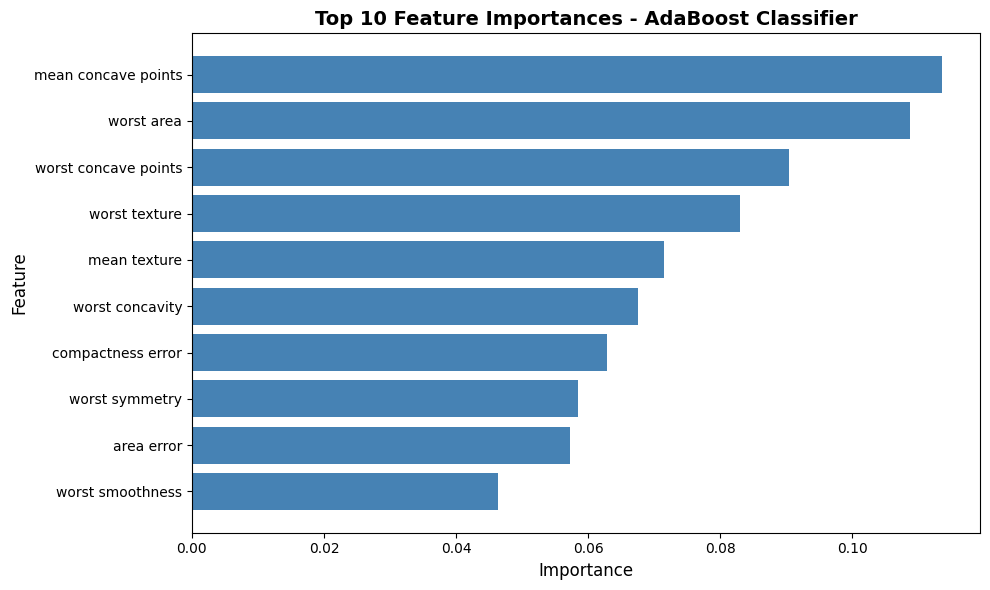

In [9]:
#ans21
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train AdaBoost Classifier
ada_clf = AdaBoostClassifier(n_estimators=50, random_state=42)
ada_clf.fit(X_train, y_train)

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Importance': ada_clf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

# Print top features
print("Top 10 Feature Importances:")
print("=" * 50)
for idx, row in feature_importance.iterrows():
    print(f"{row['Feature']:<30} {row['Importance']:.4f}")

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 10 Feature Importances - AdaBoost Classifier', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

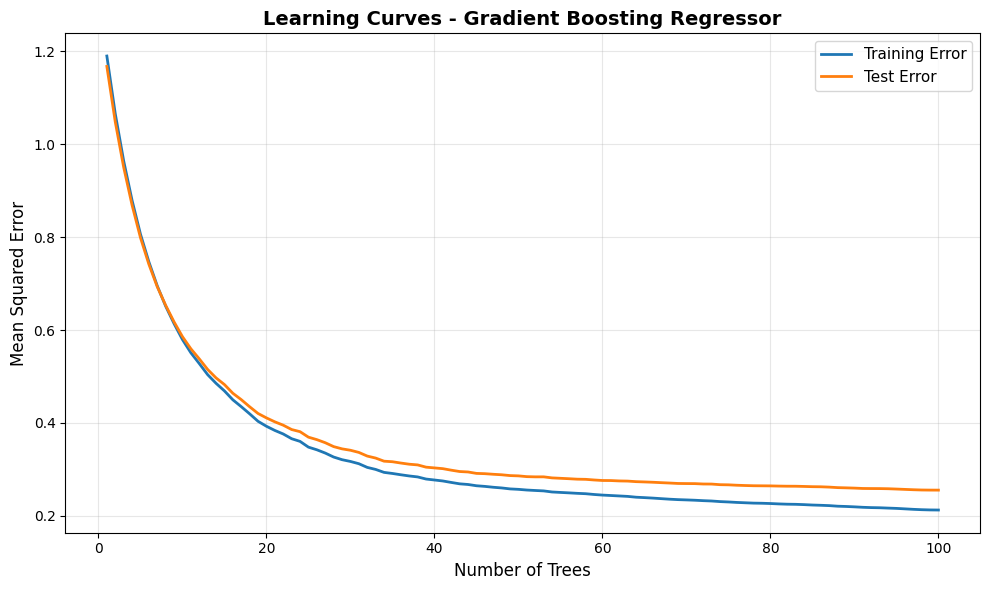

Final Training MSE: 0.2126
Final Test MSE: 0.2554
Optimal number of trees: 100


In [10]:
#ans 22
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
gb_reg.fit(X_train, y_train)

# Calculate training and test errors for each stage
train_errors = []
test_errors = []

for i, y_pred_train in enumerate(gb_reg.staged_predict(X_train)):
    train_errors.append(mean_squared_error(y_train, y_pred_train))

for i, y_pred_test in enumerate(gb_reg.staged_predict(X_test)):
    test_errors.append(mean_squared_error(y_test, y_pred_test))

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_errors) + 1), train_errors, label='Training Error', linewidth=2)
plt.plot(range(1, len(test_errors) + 1), test_errors, label='Test Error', linewidth=2)
plt.xlabel('Number of Trees', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Learning Curves - Gradient Boosting Regressor', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Training MSE: {train_errors[-1]:.4f}")
print(f"Final Test MSE: {test_errors[-1]:.4f}")
print(f"Optimal number of trees: {np.argmin(test_errors) + 1}")

Top 10 Feature Importances (by Gain):
mean concave points            0.3688
worst concave points           0.1821
worst perimeter                0.0743
worst radius                   0.0646
worst area                     0.0286
worst texture                  0.0285
fractal dimension error        0.0283
worst concavity                0.0283
concavity error                0.0264
mean texture                   0.0238


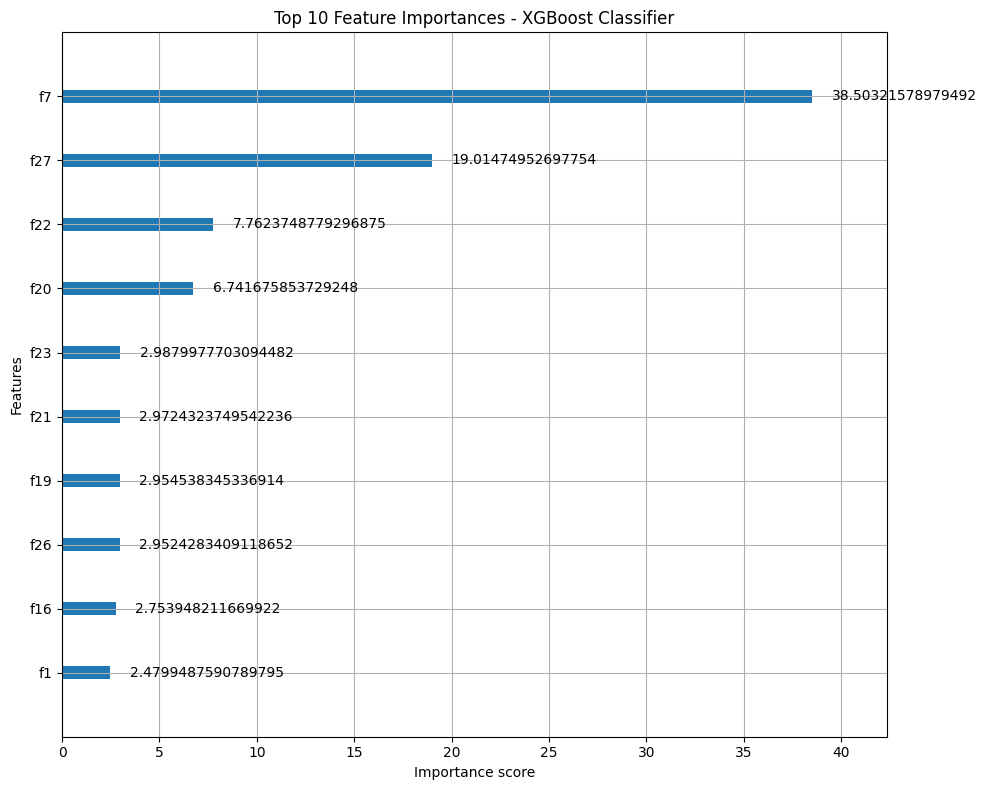

In [11]:
#ans 23
from xgboost import XGBClassifier, plot_importance
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train XGBoost Classifier
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_clf.fit(X_train, y_train)

# Print feature importance
print("Top 10 Feature Importances (by Gain):")
print("=" * 50)
feature_importance = sorted(zip(cancer.feature_names, xgb_clf.feature_importances_),
                           key=lambda x: x[1], reverse=True)
for feature, importance in feature_importance[:10]:
    print(f"{feature:<30} {importance:.4f}")

# Visualize using XGBoost's built-in plot
fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(xgb_clf, ax=ax, max_num_features=10, importance_type='gain',
                title='Top 10 Feature Importances - XGBoost Classifier')
plt.tight_layout()
plt.show()

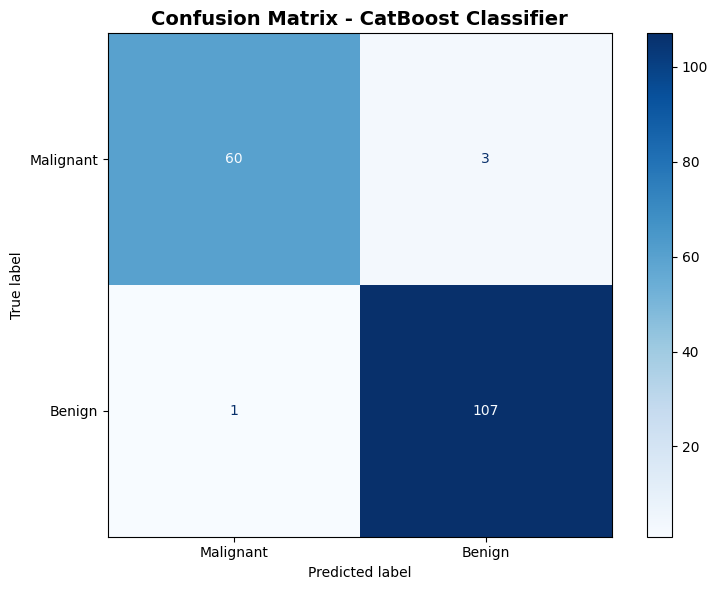

Confusion Matrix Analysis:
True Negatives (Correctly predicted Malignant): 60
False Positives (Malignant predicted as Benign): 3
False Negatives (Benign predicted as Malignant): 1
True Positives (Correctly predicted Benign): 107

Total Misclassifications: 4
Accuracy: 97.66%


In [12]:
#ans 24
from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train CatBoost Classifier
cat_clf = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=4, random_state=42, verbose=False)
cat_clf.fit(X_train, y_train)

# Make predictions
y_pred = cat_clf.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant', 'Benign'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - CatBoost Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print detailed metrics
print("Confusion Matrix Analysis:")
print("=" * 50)
print(f"True Negatives (Correctly predicted Malignant): {cm[0][0]}")
print(f"False Positives (Malignant predicted as Benign): {cm[0][1]}")
print(f"False Negatives (Benign predicted as Malignant): {cm[1][0]}")
print(f"True Positives (Correctly predicted Benign): {cm[1][1]}")
print(f"\nTotal Misclassifications: {cm[0][1] + cm[1][0]}")
print(f"Accuracy: {(cm[0][0] + cm[1][1]) / cm.sum() * 100:.2f}%")

Training AdaBoost with different numbers of estimators...
N_Estimators    Train Accuracy       Test Accuracy
------------------------------------------------------------
10                 97.24%             97.66%
25                 99.75%             97.08%
50                100.00%             97.08%
75                100.00%             97.66%
100               100.00%             97.08%
150               100.00%             97.66%
200               100.00%             98.25%
300               100.00%             97.66%


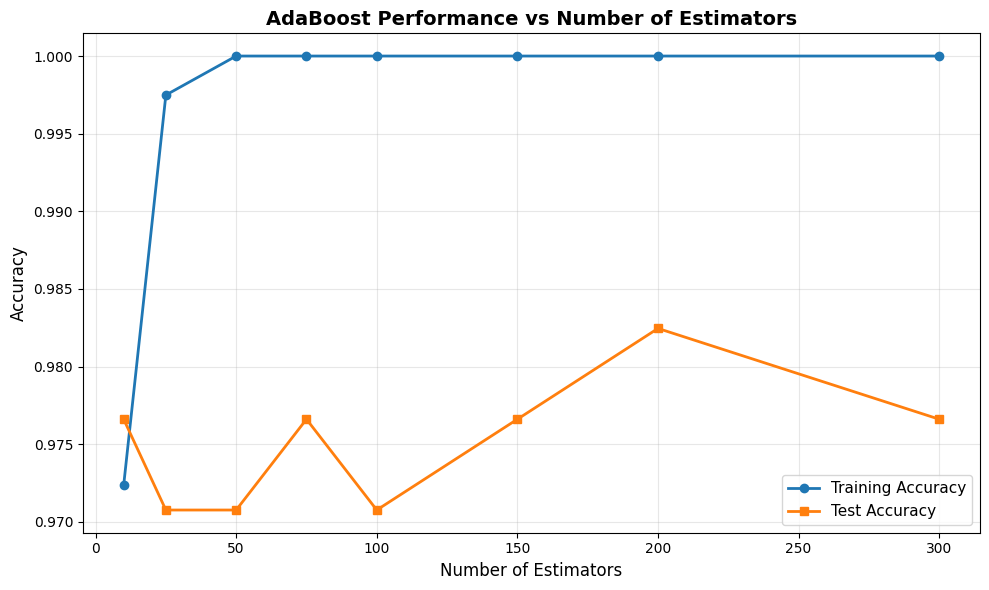


Optimal number of estimators: 200
Best test accuracy: 98.25%


In [13]:
#ans 25
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Test different numbers of estimators
n_estimators_list = [10, 25, 50, 75, 100, 150, 200, 300]
train_accuracies = []
test_accuracies = []

print("Training AdaBoost with different numbers of estimators...")
print("=" * 60)
print(f"{'N_Estimators':<15} {'Train Accuracy':<20} {'Test Accuracy'}")
print("-" * 60)

for n_est in n_estimators_list:
    # Train model
    ada_clf = AdaBoostClassifier(n_estimators=n_est, random_state=42)
    ada_clf.fit(X_train, y_train)

    # Calculate accuracies
    train_acc = accuracy_score(y_train, ada_clf.predict(X_train))
    test_acc = accuracy_score(y_test, ada_clf.predict(X_test))

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"{n_est:<15} {train_acc*100:>8.2f}%          {test_acc*100:>8.2f}%")

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, train_accuracies, marker='o', label='Training Accuracy', linewidth=2)
plt.plot(n_estimators_list, test_accuracies, marker='s', label='Test Accuracy', linewidth=2)
plt.xlabel('Number of Estimators', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('AdaBoost Performance vs Number of Estimators', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find optimal number
optimal_idx = test_accuracies.index(max(test_accuracies))
print(f"\nOptimal number of estimators: {n_estimators_list[optimal_idx]}")
print(f"Best test accuracy: {max(test_accuracies)*100:.2f}%")

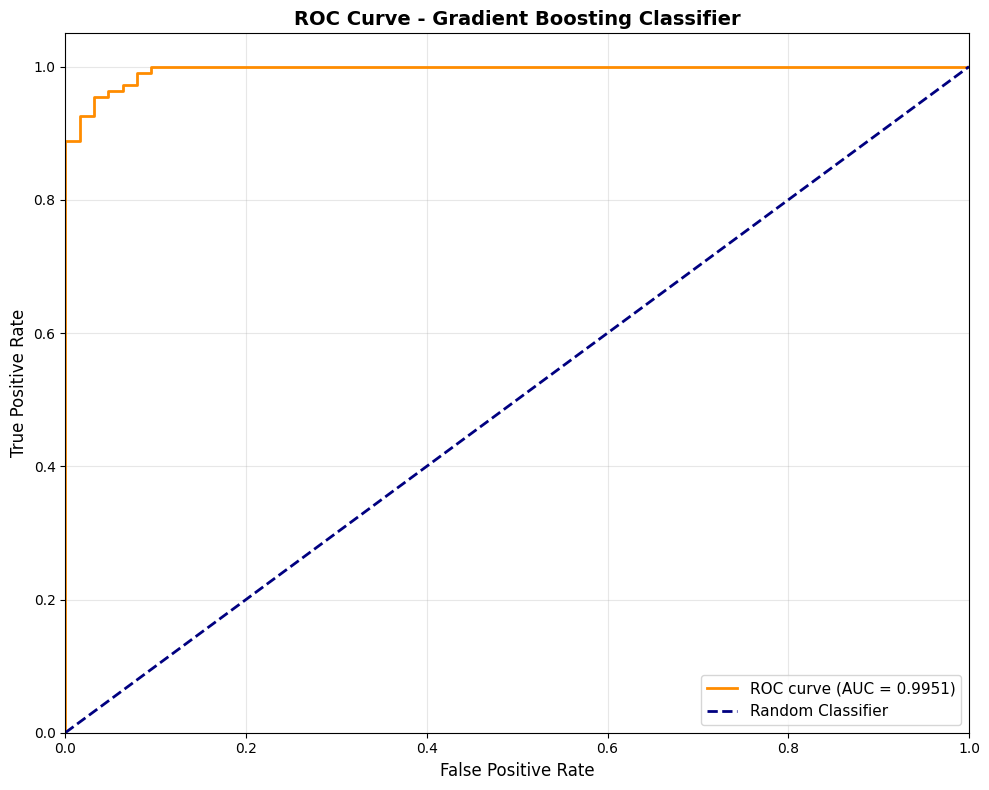

ROC Curve Analysis:
ROC-AUC Score: 0.9951
Interpretation: The model has excellent discriminative ability


In [14]:
#ans 26
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_clf.fit(X_train, y_train)

# Get predicted probabilities
y_pred_proba = gb_clf.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Gradient Boosting Classifier', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("ROC Curve Analysis:")
print("=" * 50)
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Interpretation: The model has {'excellent' if roc_auc > 0.9 else 'good'} discriminative ability")

In [16]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing # Changed from load_boston
import numpy as np

# Load dataset
housing = fetch_california_housing() # Changed from load_boston
X, y = housing.data, housing.target # Extract data and target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Parameter grid for learning rate
param_grid = {'learning_rate': [0.01, 0.05, 0.1, 0.2]}

# Grid search
grid = GridSearchCV(xgb, param_grid, scoring='neg_mean_squared_error', cv=5)
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print("Best learning rate:", grid.best_params_['learning_rate'])
print("Test MSE:", mse)

Best learning rate: 0.2
Test MSE: 0.21596203014190907


In [17]:
#ans 28
from catboost import CatBoostClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Create imbalanced data
X, y = make_classification(n_samples=1000, n_features=10, weights=[0.9, 0.1], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model without class weights
model_normal = CatBoostClassifier(verbose=0, random_state=42)
model_normal.fit(X_train, y_train)
y_pred1 = model_normal.predict(X_test)

# Model with class weights
weights = {0: 1, 1: 9}
model_weighted = CatBoostClassifier(class_weights=weights, verbose=0, random_state=42)
model_weighted.fit(X_train, y_train)
y_pred2 = model_weighted.predict(X_test)

print("Without Class Weights:\n", classification_report(y_test, y_pred1))
print("With Class Weights:\n", classification_report(y_test, y_pred2))


Without Class Weights:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       175
           1       0.94      0.60      0.73        25

    accuracy                           0.94       200
   macro avg       0.94      0.80      0.85       200
weighted avg       0.94      0.94      0.94       200

With Class Weights:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       175
           1       0.85      0.68      0.76        25

    accuracy                           0.94       200
   macro avg       0.90      0.83      0.86       200
weighted avg       0.94      0.94      0.94       200



Learning Rate: 0.01, Accuracy: 0.8400
Learning Rate: 0.1, Accuracy: 0.8400
Learning Rate: 0.5, Accuracy: 0.8650
Learning Rate: 1.0, Accuracy: 0.8500


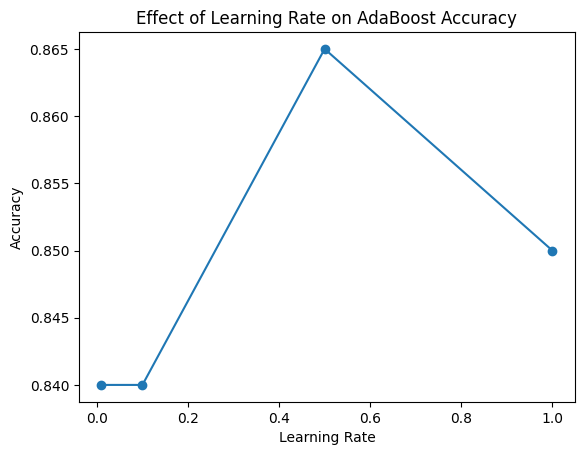

In [18]:
#ans 29
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Generate dataset
X, y = make_classification(n_samples=1000, n_features=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

learning_rates = [0.01, 0.1, 0.5, 1.0]
accuracies = []

for lr in learning_rates:
    model = AdaBoostClassifier(n_estimators=100, learning_rate=lr, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"Learning Rate: {lr}, Accuracy: {acc:.4f}")

plt.plot(learning_rates, accuracies, marker='o')
plt.title("Effect of Learning Rate on AdaBoost Accuracy")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.show()


In [19]:
#ans 30
from xgboost import XGBClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score

# Load dataset
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost classifier
model = XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss', random_state=42)
model.fit(X_train, y_train)

# Predict probabilities
y_prob = model.predict_proba(X_test)
y_pred = model.predict(X_test)

# Evaluate
loss = log_loss(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)

print("Log-loss:", loss)
print("Accuracy:", acc)


Log-loss: 0.009290131121575453
Accuracy: 1.0
